# CS441: Applied ML - HW 4

## Part I: Clustering and Fast Retrieval

Include all the code for Part 1 in this section

In [ ]:
!apt install libomp-dev
!pip install faiss-cpu

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following additional packages will be installed:
  libomp-10-dev libomp5-10
Suggested packages:
  libomp-10-doc
The following NEW packages will be installed:
  libomp-10-dev libomp-dev libomp5-10
0 upgraded, 3 newly installed, 0 to remove and 24 not upgraded.
Need to get 351 kB of archives.
After this operation, 2,281 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu focal/universe amd64 libomp5-10 amd64 1:10.0.0-4ubuntu1 [300 kB]
Get:2 http://archive.ubuntu.com/ubuntu focal/universe amd64 libomp-10-dev amd64 1:10.0.0-4ubuntu1 [47.7 kB]
Get:3 http://archive.ubuntu.com/ubuntu focal/universe amd64 libomp-dev amd64 1:10.0-50~exp1 [2,824 B]
Fetched 351 kB in 0s (2,308 kB/s)
Selecting previously unselected package libomp5-10:amd64.
(Reading database ... 122349 files and directories currently installed.)
Preparing to unpack .../libomp5-10_1%3a10.0.0-4ubuntu1_amd6

In [ ]:
# initialization code
import numpy as np
from keras.datasets import mnist
%matplotlib inline
from matplotlib import pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
import time
import faiss
from google.colab import drive
from google.colab.patches import cv2_imshow
import cv2
# loads MNIST data and reformat to 768-d vectors with values in range 0 to 1
# splits into train/val/test sets and provides indices for subsets of train
def load_mnist():
  (x_train, y_train), (x_test, y_test) = mnist.load_data()
  x_train = np.reshape(x_train, (len(x_train), 28*28))
  x_test = np.reshape(x_test, (len(x_test), 28*28))
  maxval = x_train.max()
  x_train = x_train/maxval
  x_test = x_test/maxval
  x_val = x_train[:10000]
  y_val = y_train[:10000]
  x_train = x_train[10000:]
  y_train = y_train[10000:]
  train_indices = dict()
  train_indices['xs'] = np.arange(50)
  train_indices['s'] = np.arange(500)
  train_indices['m'] = np.arange(5000)
  train_indices['all'] = np.arange(50000)
  return (x_train, y_train), (x_val, y_val), (x_test, y_test), train_indices

# displays a set of mnist images (can print 1 row OR 1 column)
def display_mnist(x, subplot_rows=1, subplot_cols=1):
  s = np.ceil(max(subplot_rows, subplot_cols)/10)
  if subplot_rows>1 or subplot_cols>1:
      fig, ax = plt.subplots(subplot_rows, subplot_cols, figsize=(15,15))
      for i in range(len(x)):
        ax[i].imshow(np.reshape(x[i], (28,28)), cmap='gray')
        ax[i].axis('off')
  else:
      plt.imshow(np.reshape(x, (28,28)), cmap='gray')
      plt.axis('off')
  plt.show()

# counts the number of examples per class
def class_count_mnist(y):
  count = np.zeros((10,),dtype='uint32')
  for i in np.arange(10):
    count[i] = sum(y==i)
  return count

11490434/11490434 [==============================] - 1s 0us/step


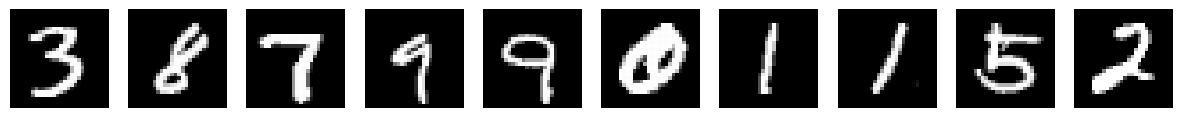

Total size: train=50000, val=10000, test =10000
Train subset size: xs=50, s=500, m=5000, all=50000
Class count for s: [56 57 51 49 46 46 50 51 40 54]


In [ ]:
# example of using MNIST load, display, indices, and count functions
(x_train, y_train), (x_val, y_val), (x_test, y_test), train_indices = load_mnist()
display_mnist(x_train[:10],1,10)
print('Total size: train={}, val={}, test ={}'.format(len(x_train), len(x_val), len(x_test)))
print('Train subset size: xs={}, s={}, m={}, all={}'.format(len(train_indices['xs']),len(train_indices['s']),len(train_indices['m']),len(train_indices['all'])))
print('Class count for s: {}'.format(class_count_mnist(y_train[train_indices['s']])))

In [ ]:
## Helper functions

# Returns the purity of the clustering according to labels, 
# and the label counts of each cluster
def get_purity(labels, cluster_idx):
  nclasses = int(max(labels)+1)
  nidx = int(max(cluster_idx)+1)
  counts = np.zeros((nidx, nclasses), np.int32)
  for i in range(len(labels)):
    c = labels[i]
    idx = cluster_idx[i]
    counts[idx, c]+=1
  purity = np.sum(np.max(counts, axis=1))/len(cluster_idx)
  return purity, counts

# Returns an index list that can be used to re-order the counts according to 
# which label is most common 
def get_cluster_order(counts):
  idx = np.argmax(counts, axis=1)
  idx = np.argsort(idx)
  return idx 

###*Problem* 1.1 Clustering

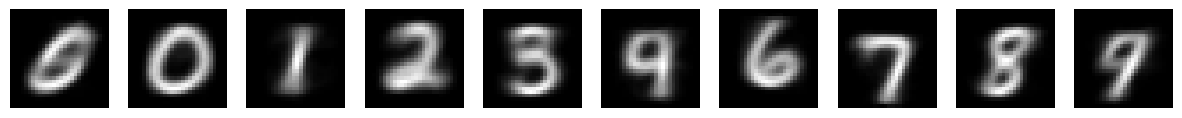

For K = 10, the Mean_distance is: 39.5686, and the Purity is = 0.6187


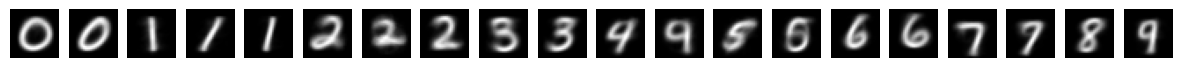

For K = 20, the Mean_distance is: 35.5241, and the Purity is = 0.7255


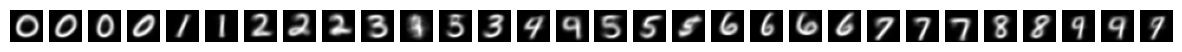

For K = 30, the Mean_distance is: 33.4309, and the Purity is = 0.7531


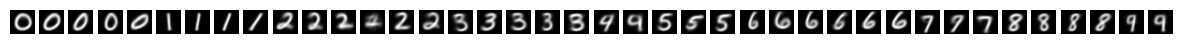

For K = 40, the Mean_distance is: 32.1001, and the Purity is = 0.7801


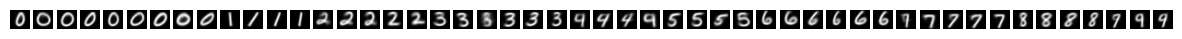

For K = 50, the Mean_distance is: 31.0037, and the Purity is = 0.7983


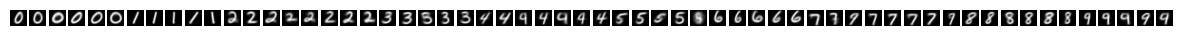

For K = 60, the Mean_distance is: 30.1783, and the Purity is = 0.8223


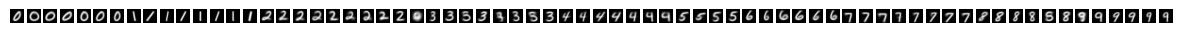

For K = 70, the Mean_distance is: 29.7197, and the Purity is = 0.8474


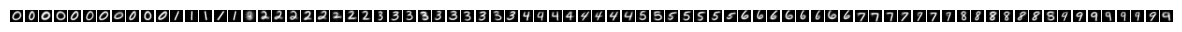

For K = 80, the Mean_distance is: 29.0650, and the Purity is = 0.8569


For K = 90, the Mean_distance is: 28.7054, and the Purity is = 0.8628


For K = 100, the Mean_distance is: 28.3855, and the Purity is = 0.8550


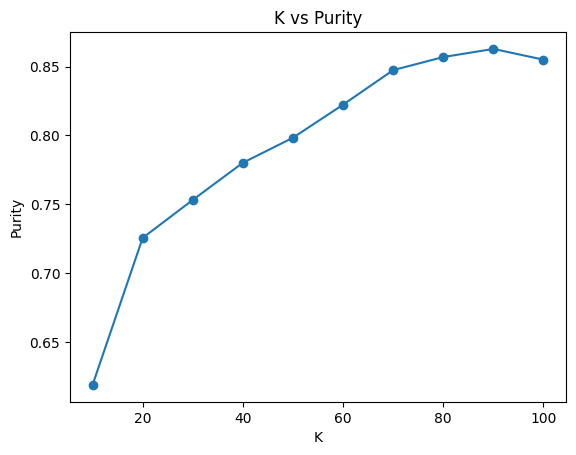

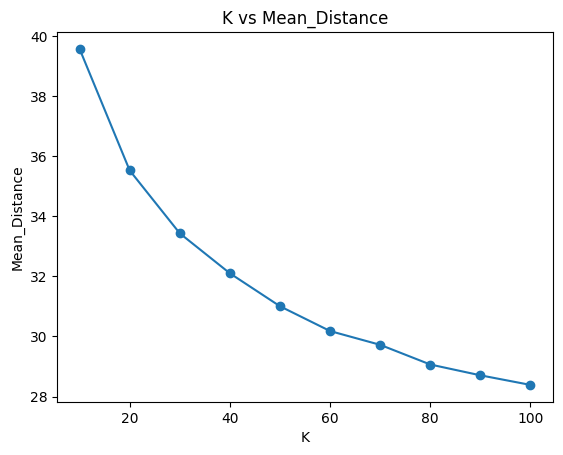

In [ ]:
# set dimensions
dim = x_train.shape[1]

# Set the number of clusters
clusters =  [10, 20, 30,40,50,60,70,80,90, 100]

purity_k = []
mean_k = []

for K in clusters:
  # Initialize the k-means clustering object
  kmeans = faiss.Kmeans(dim, K)

  # Train the k-means model
  kmeans.train(x_train)

  # Assign each data point to a cluster
  data_point, index = kmeans.index.search(x_test, 1)

  cluster_idx = index.reshape(-1)
  dist = data_point.reshape(-1)

  md = dist.mean()
  mean_k.append(md)

  # Record and print Purity
  purity, counts = get_purity(y_test, cluster_idx)
  purity_k.append(purity)
  
  # Get Cluster indexes & Display the centroids
  idx = get_cluster_order(counts)
  display_mnist(kmeans.centroids[idx, :], 1, K)
  
  # Record and print Average Distance
  print(f"For K = {K}, the Mean_distance is: {md:.4f}, and the Purity is = {purity:.4f}")

# Plot K vs Purity and K vs Mean_Distances
plt.figure()
plt.plot(clusters, purity_k, marker='o')
plt.xlabel("K")
plt.ylabel("Purity")
plt.title("K vs Purity")
plt.show()

plt.figure()
plt.plot(clusters, mean_k, marker='o')
plt.xlabel("K")
plt.ylabel("Mean_Distance")
plt.title("K vs Mean_Distance")
plt.show()

As you increase K, do you expect the purity to increase? Why or why not?

As I increase K, I expect the purity to increase. I don’t expect the purity to always increase by a lot but I do expect the purity to always increase at least a little. I say this because the more samples there are, the more likely it is that the images that look similar will be clustered together. Which will lead to an increase in purity. However, based on the K VS Purity plot above, as K increases, the purity doesn’t always increase. Most of the time the purity increased, but when K was equal to 100, the purity decreased. I think this is due to overfitting.

In a given run, is the average distance of a sample to centroid guaranteed to monotonically decrease (or not change) with each iteration? Why or why not?

Yes, in a given run, the average distance of a sample to centroid is guaranteed to monotonically decrease (or not change) with each iteration. I say this because I believe that with each iteration, the k-means algorithm decreases the sum of squared distances from each point to the centroid that it is related to. Basically, the centroids are allocated closer towards the average of the samples in every single cluster. So, the average distance will always decrease or the average distance will not change. An example of this is shown in the K VS Mean_Distance plot above.

If you do enough iterations, is K-means guaranteed to give you the optimal clustering that minimizes the sum of distances between each sample and its center? Why or why not?

If I do enough iterations, the k-means algorithm is not guaranteed to give me the optimal clustering that minimizes the sum of distances between each sample and its center. I say this because the k-means algorithm is sensitive  when it comes to the centroids that have just been placed. Although the k-means algorithm is guaranteed to find the local optimum that minimizes the sum of distances between each sample and its center, it is not guaranteed to find the global optimum that minimizes the sum of distances between each sample and its center.

Does improving the K-means objective (i.e. achieving lower mean squared error) necessarily improve expected purity? Why or why not?

Improving the k-means objective does not necessarily improve the expected purity. I say this because, the k-means objective is to achieve a lower mean squared error. When we achieve a lower mean squared error, the clusters will become smaller. In other words, the clusters will become more dense. When this happens, there is a possibility that samples from different clusters that are close to one another will be grouped together. Due to this, improving the K-means objective does not necessarily mean that the purity will improve.

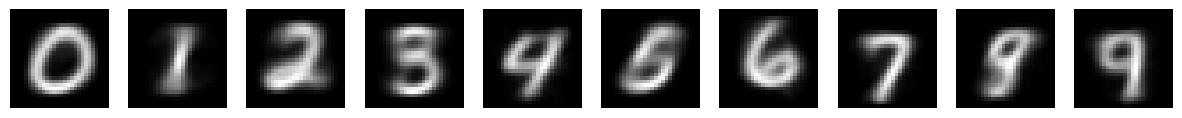

For K = 10, the Mean_distance is: 39.7596, and the Purity is = 0.5965


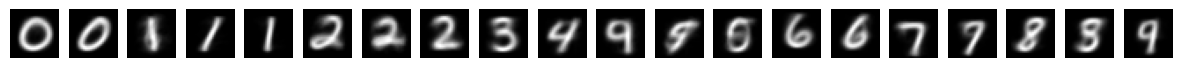

For K = 20, the Mean_distance is: 35.9530, and the Purity is = 0.6670


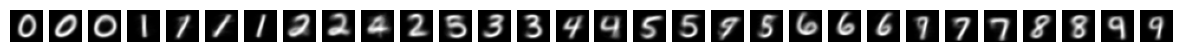

For K = 30, the Mean_distance is: 33.5744, and the Purity is = 0.7544


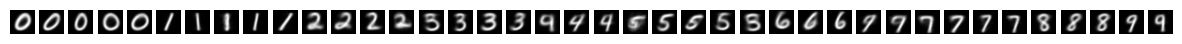

For K = 40, the Mean_distance is: 32.3689, and the Purity is = 0.7885


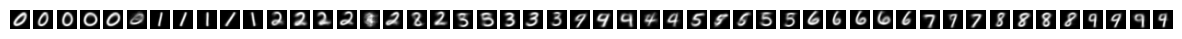

For K = 50, the Mean_distance is: 31.4164, and the Purity is = 0.7621


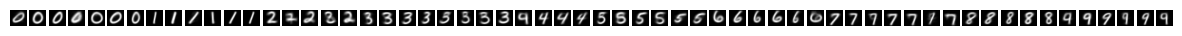

For K = 60, the Mean_distance is: 30.6432, and the Purity is = 0.8094


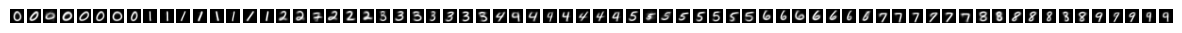

For K = 70, the Mean_distance is: 29.8838, and the Purity is = 0.8234


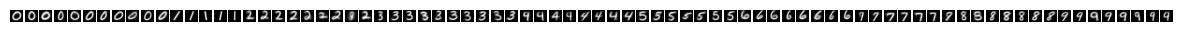

For K = 80, the Mean_distance is: 29.4157, and the Purity is = 0.8367


For K = 90, the Mean_distance is: 29.0087, and the Purity is = 0.8352


For K = 100, the Mean_distance is: 28.5666, and the Purity is = 0.8482


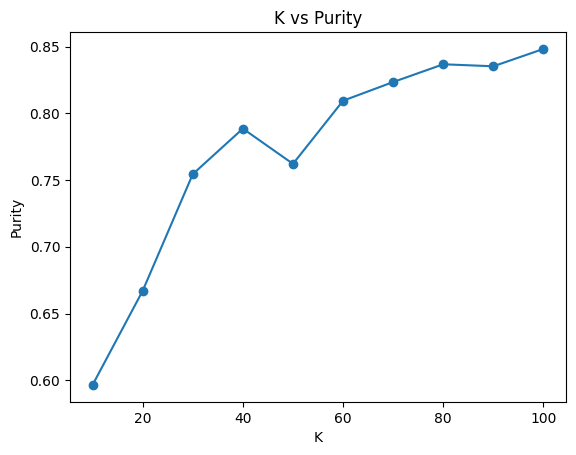

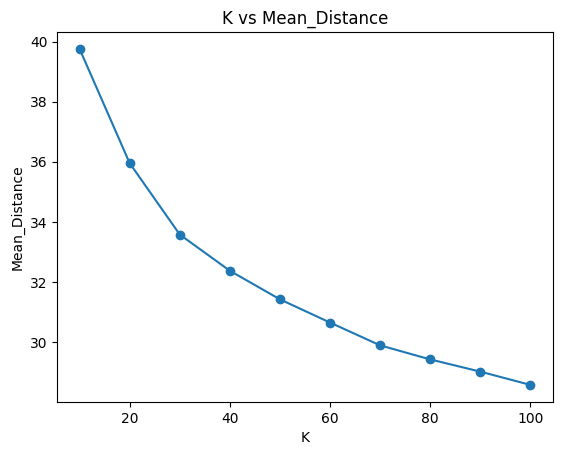

In [ ]:
# set dimensions
dim = x_train.shape[1]

# Set the number of clusters
clusters =  [10, 20, 30,40,50,60,70,80,90, 100]

purity_k = []
mean_k = []

for K in clusters:
  # Initialize the k-means clustering object
  kmeans = faiss.Kmeans(dim, K, niter=5, nredo=5, verbose=True)

  # Train the k-means model
  kmeans.train(x_train)

  # Assign each data point to a cluster
  data_point, index = kmeans.index.search(x_test, 1)

  cluster_idx = index.reshape(-1)
  dist = data_point.reshape(-1)

  md = dist.mean()
  mean_k.append(md)

  # Record and print Purity
  purity, counts = get_purity(y_test, cluster_idx)
  purity_k.append(purity)
  
  # Get Cluster indexes & Display the centroids
  idx = get_cluster_order(counts)
  display_mnist(kmeans.centroids[idx, :], 1, K)
  
  # Record and print Average Distance
  print(f"For K = {K}, the Mean_distance is: {md:.4f}, and the Purity is = {purity:.4f}")

# Plot K vs Purity and K vs Mean_Distances
plt.figure()
plt.plot(clusters, purity_k, marker='o')
plt.xlabel("K")
plt.ylabel("Purity")
plt.title("K vs Purity")
plt.show()

plt.figure()
plt.plot(clusters, mean_k, marker='o')
plt.xlabel("K")
plt.ylabel("Mean_Distance")
plt.title("K vs Mean_Distance")
plt.show()

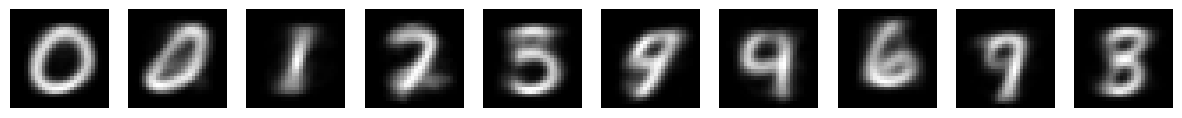

For K = 10, the Mean_distance is: 40.0937, and the Purity is = 0.5431


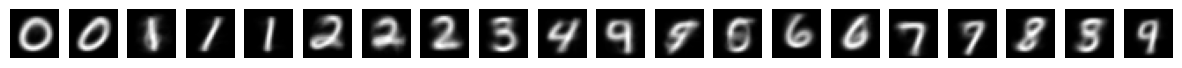

For K = 20, the Mean_distance is: 36.0770, and the Purity is = 0.6583


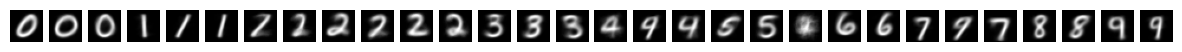

For K = 30, the Mean_distance is: 33.9156, and the Purity is = 0.7216


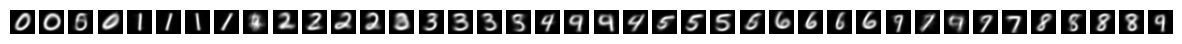

For K = 40, the Mean_distance is: 32.7802, and the Purity is = 0.7350


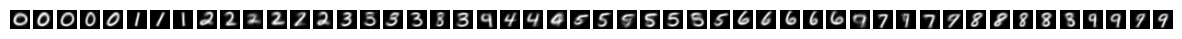

For K = 50, the Mean_distance is: 31.5040, and the Purity is = 0.7870


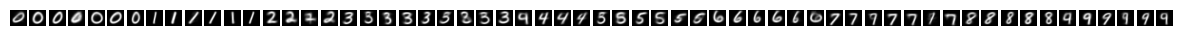

For K = 60, the Mean_distance is: 30.7529, and the Purity is = 0.8002


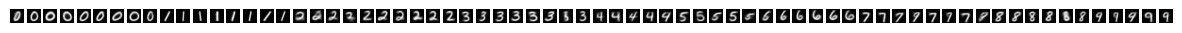

For K = 70, the Mean_distance is: 30.0751, and the Purity is = 0.8148


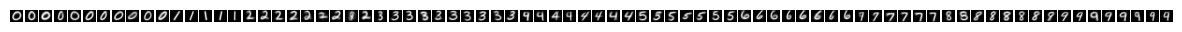

For K = 80, the Mean_distance is: 29.5496, and the Purity is = 0.8320


For K = 90, the Mean_distance is: 29.1221, and the Purity is = 0.8296


For K = 100, the Mean_distance is: 28.6649, and the Purity is = 0.8352


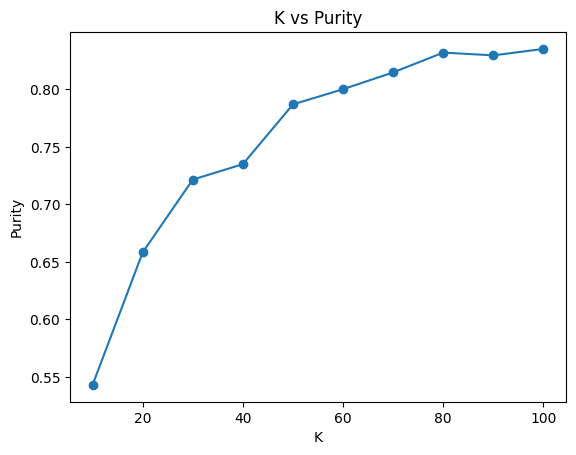

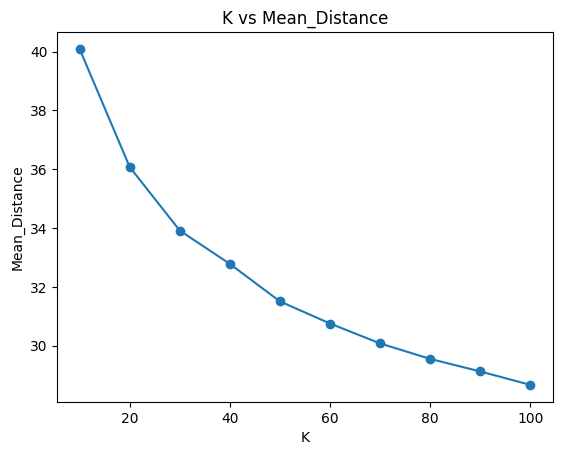

In [ ]:
# set dimensions
dim = x_train.shape[1]

# Set the number of clusters
clusters =  [10, 20, 30,40,50,60,70,80,90, 100]

purity_k = []
mean_k = []

for K in clusters:
  # Initialize the k-means clustering object
  kmeans = faiss.Kmeans(dim, K, niter=4, nredo=4, verbose=True)

  # Train the k-means model
  kmeans.train(x_train)

  # Assign each data point to a cluster
  data_point, index = kmeans.index.search(x_test, 1)

  cluster_idx = index.reshape(-1)
  dist = data_point.reshape(-1)

  md = dist.mean()
  mean_k.append(md)

  # Record and print Purity
  purity, counts = get_purity(y_test, cluster_idx)
  purity_k.append(purity)
  
  # Get Cluster indexes & Display the centroids
  idx = get_cluster_order(counts)
  display_mnist(kmeans.centroids[idx, :], 1, K)
  
  # Record and print Average Distance
  print(f"For K = {K}, the Mean_distance is: {md:.4f}, and the Purity is = {purity:.4f}")

# Plot K vs Purity and K vs Mean_Distances
plt.figure()
plt.plot(clusters, purity_k, marker='o')
plt.xlabel("K")
plt.ylabel("Purity")
plt.title("K vs Purity")
plt.show()

plt.figure()
plt.plot(clusters, mean_k, marker='o')
plt.xlabel("K")
plt.ylabel("Mean_Distance")
plt.title("K vs Mean_Distance")
plt.show()

### Problem 1.2 Fast Retrieval

In [ ]:
# Brute Force (IndexFlatL2)

# set dimensions
dim = x_train.shape[1]

# Initialize the index for Brute Force
index_flatl2 = faiss.IndexFlatL2(dim)

start_time = time.time()

# Add Data & Print time to add
index_flatl2.add(x_train)

add_time = time.time()

# Perform Search and Compute Time required
_, search = index_flatl2.search(x_test, 1)

search_time = time.time()

# Compute Test Error
test_error = (y_test != y_train[search.reshape(-1)]).mean()

AT = add_time-start_time
ST = search_time-add_time

print(f"Brute Force: The Test Error Is: {test_error:.4f}, The Add Time Is: {AT:.4f}s, The Search Time Is: {ST:.4f}s")

Brute Force: The Test Error Is: 0.0331, The Add Time Is: 0.1038s, The Search Time Is: 11.5235s


In [ ]:
# LSH when nbits = dim

# set dimensions
dim = x_train.shape[1]

nbits = dim

# Initialize the index for LSH
index_lsh = faiss.IndexLSH(dim, nbits)

start_time = time.time()

# Add Data & Print time to add
index_lsh.add(x_train)

add_time = time.time()

# Perform Search and Compute Time required
_, search = index_lsh.search(x_test, 1)

search_time = time.time()

# Compute Test Error
test_error = (y_test != y_train[search.reshape(-1)]).mean()

AT = add_time-start_time
ST = search_time-add_time

print(f"LSH: The nbits Is: {nbits}, The Test Error Is: {test_error:.4f}, The Add Time Is: {AT:.4f}s, The Search Time Is: {ST:.4f}s")

LSH: The nbits Is: 784, The Test Error Is: 0.0373, The Add Time Is: 0.9650s, The Search Time Is: 5.6733s


In [ ]:
# LSH when nbits = dim // 2

# set dimensions
dim = x_train.shape[1]

nbits = dim // 2

# Initialize the index for LSH
index_lsh = faiss.IndexLSH(dim, nbits)

start_time = time.time()

# Add Data & Print time to add
index_lsh.add(x_train)

add_time = time.time()

# Perform Search and Compute Time required
_, search = index_lsh.search(x_test, 1)

search_time = time.time()

# Compute Test Error
test_error = (y_test != y_train[search.reshape(-1)]).mean()

AT = add_time-start_time
ST = search_time-add_time

print(f"LSH: The nbits Is: {nbits}, The Test Error Is: {test_error:.4f}, The Add Time Is: {AT:.4f}s, The Search Time Is: {ST:.4f}s")

LSH: The nbits Is: 392, The Test Error Is: 0.0425, The Add Time Is: 0.5031s, The Search Time Is: 3.9151s


In [ ]:
# LSH when nbits = dim * 2

# set dimensions
dim = x_train.shape[1]

nbits = dim * 2

# Initialize the index for LSH
index_lsh = faiss.IndexLSH(dim, nbits)

start_time = time.time()

# Add Data & Print time to add
index_lsh.add(x_train)

add_time = time.time()

# Perform Search and Compute Time required
_, search = index_lsh.search(x_test, 1)

search_time = time.time()

# Compute Test Error
test_error = (y_test != y_train[search.reshape(-1)]).mean()

AT = add_time-start_time
ST = search_time-add_time

print(f"LSH: The nbits Is: {nbits}, The Test Error Is: {test_error:.4f}, The Add Time Is: {AT:.4f}s, The Search Time Is: {ST:.4f}s")

LSH: The nbits Is: 1568, The Test Error Is: 0.0318, The Add Time Is: 1.8540s, The Search Time Is: 12.0551s


## Part 2: Estimating PDFs

In [ ]:
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import time
import faiss
from google.colab import drive
from google.colab.patches import cv2_imshow
import cv2

drive.mount('/content/drive')
datadir = "/content/drive/My Drive/CS441/hw4/" # revise as needed
im = cv2.imread(datadir + '3985783648_4702b45d13_c.jpg')
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)/255  # converts to RGB ordering and values between 0 and 1
crop = cv2.imread(datadir + '3985783648_4702b45d13_c_crop.jpg')
crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)/255

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def display_score_maps(im, score_map, thresh):
  '''
    Input: im (h, w, 3): RGB image
           score_map (h, w, 1) or (h*w, 1)
           thresh: floating point threshold, typically between -2 and 2
  '''
  plt.imshow(im)
  plt.axis('off')
  plt.show()
  plt.imshow(np.reshape(score_map, (im.shape[:2])))
  plt.axis('off')
  plt.show()
  plt.imshow(np.reshape(score_map>thresh, (im.shape[0], im.shape[1])), cmap='gray')
  plt.axis('off')
  plt.show()
  plt.imshow(np.tile(np.reshape(score_map>thresh, (im.shape[0], im.shape[1], 1)), (1,1,3))*im)
  plt.axis('off')
  plt.show()

#### Method 1 (Per-dimension discrete pdf)

In [ ]:
# estimate discrete pdf
def estimate_discrete_pdf(x, K, prior=1):
  '''
    Input: x(nx, ): an array of discrete values from 0 to K-1
           K: number of possible discrete values
           prior: initial count for each discrete value
    Output: p(nvalues, ): p[i] is the estimated probability of discrete value i
    
    This function can be used for Method 1 and Method 2
  '''

  p = np.ones(K,)*prior # initialize p 
  # TO DO: 
  # (1) loop through values
  for v in range(x.shape[0]):
    # (2) increment element of p corresponding to each value
    p[x[v]] += 1
  # (3) divide by sum of p    
  # Count the occurrences of each discrete value in x
  p /= p.sum()

  return p

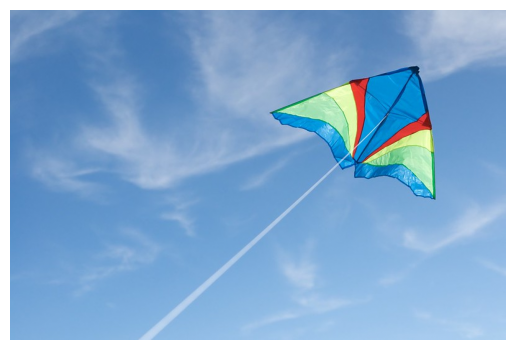

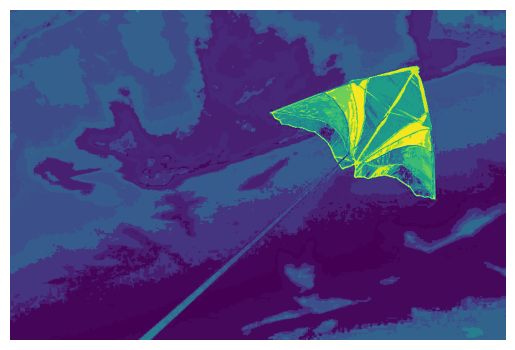

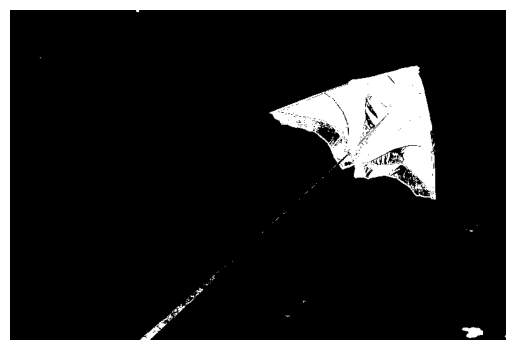

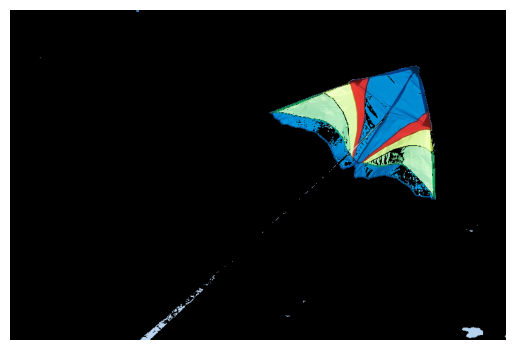

In [ ]:
# set number of bins K
K = 13

# reshape pixels to (h*w, 3)
CI = crop.reshape(-1, 3)
FI = im.reshape(-1, 3)

# convert continuous values to discrete values ranging from 0 to K-1 
# e.g. x-->min(int(x*K), K-1) if x ranges from 0 to 1
CD = np.minimum((CI * K).astype(int), K - 1)
FD = np.minimum((FI * K).astype(int), K - 1)

# get pdf for each dimension using estimate_discrete_pdf
CPDFLIST = []
FPDFLIST = []

for v in range(3):
  CPDF = estimate_discrete_pdf(CD[:, v], K)
  CPDFLIST.append(CPDF)
  FPDF = estimate_discrete_pdf(FD[:, v], K)
  FPDFLIST.append(FPDF)

# estimate score for each pixel in full image according to log pdfs
PDFLOGLIST = []

for v in range(3):
    PDFL = np.log(CPDFLIST[v][FD[:, v]] / FPDFLIST[v][FD[:, v]])
    PDFLOGLIST.append(PDFL)

# display
ScoreMapImage = np.sum(PDFLOGLIST, axis=0)
ThresholdImage = 0.6

display_score_maps(im, ScoreMapImage, ThresholdImage)

#### Method 2 (K-means)

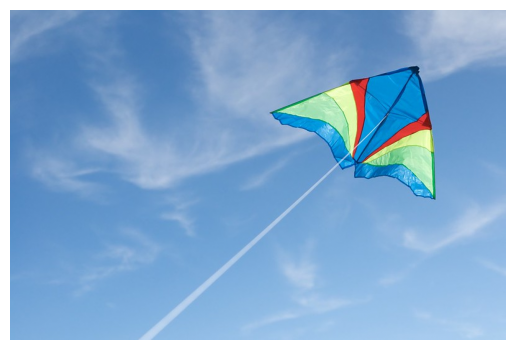

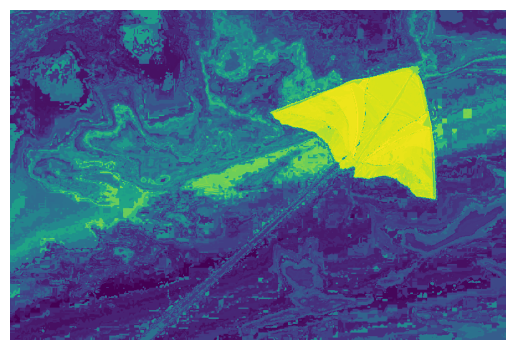

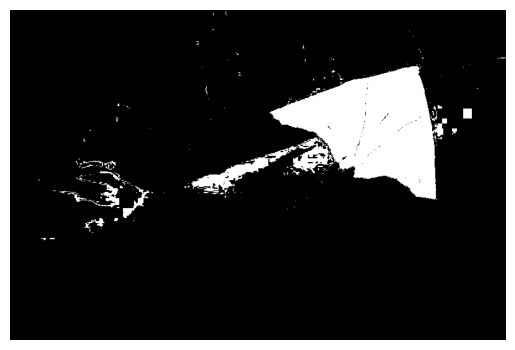

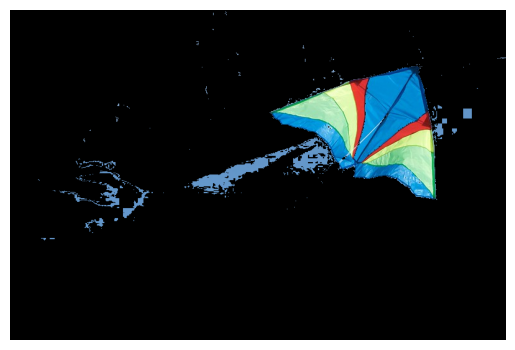

In [ ]:
import faiss

# set K
K = 501

# reshape pixels to (h*w, 3)
CI = crop.reshape(-1, 3)
FI = im.reshape(-1, 3)

# discretize all three color channels together using KMeans
kmeans = faiss.Kmeans(3, K)
kmeans.train(FI)

_, CISearch = kmeans.index.search(CI, 1)
_, FISearch = kmeans.index.search(FI, 1)

# get pdf over discrete values
CIF = CISearch.flatten()
FIF = FISearch.flatten()

CPDFLIST = estimate_discrete_pdf(CISearch, K)
FPDFLIST = estimate_discrete_pdf(FISearch, K)

# estimate score for each pixel in full image according to log pdfs
PDFL = np.log(CPDFLIST[FISearch] / FPDFLIST[FISearch])
PDFLF = PDFL.flatten()

# display
ScoreMapImage = PDFL
ThresholdImage = 0.6

display_score_maps(im, ScoreMapImage, ThresholdImage)

#### Method 3 (GMM)

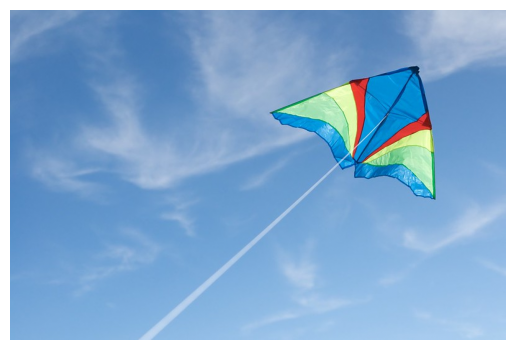

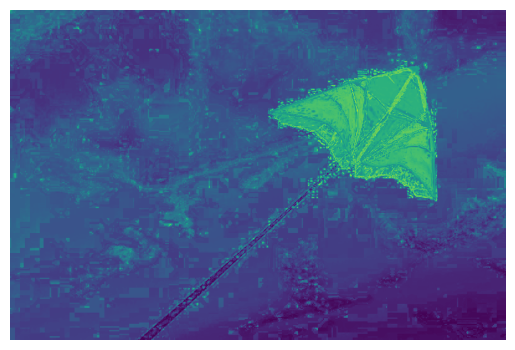

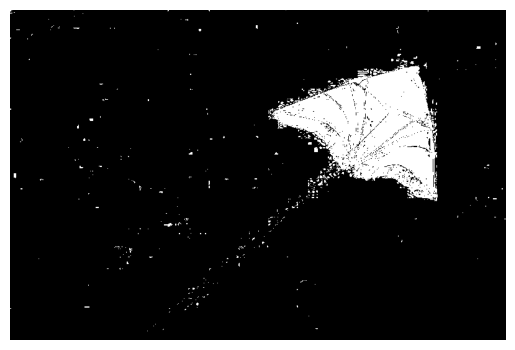

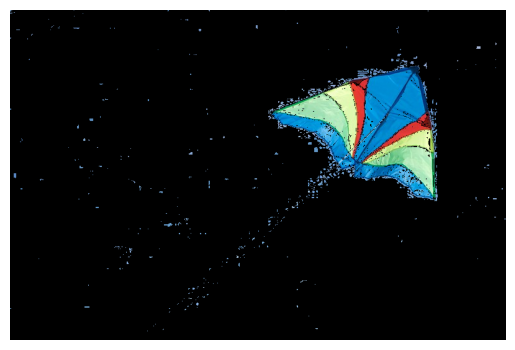

In [ ]:
from sklearn.mixture import GaussianMixture

# reshape pixels to (h*w, 3)
CI = crop.reshape(-1, 3)
FI = im.reshape(-1, 3)

# get joint pdf using GMMs (choose number of components and other parameters)
JPDFGMMCI = GaussianMixture(n_components=8, covariance_type='full')
JPDFGMMFI = GaussianMixture(n_components=8, covariance_type='full')

JPDFGMMCI.fit(CI)
JPDFGMMFI.fit(FI)

# estimate score for each pixel in full image according to log pdfs
LPDFCI = JPDFGMMCI.score_samples(FI)
LPDFFI = JPDFGMMFI.score_samples(FI)

# display
ScoreMapImage = LPDFCI - LPDFFI
ThresholdImage = 0.6

display_score_maps(im, ScoreMapImage, ThresholdImage)

## Part 3: PCA and Data Compression

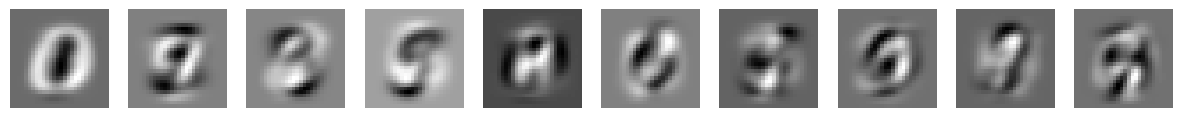

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import faiss

(x_train, y_train), (x_val, y_val), (x_test, y_test), train_indices = load_mnist()

# Compute the principal components using x_train
pca = PCA()
pca.fit(x_train)

# Display First 10 Components
display_mnist(pca.components_[:10], 1, 10)

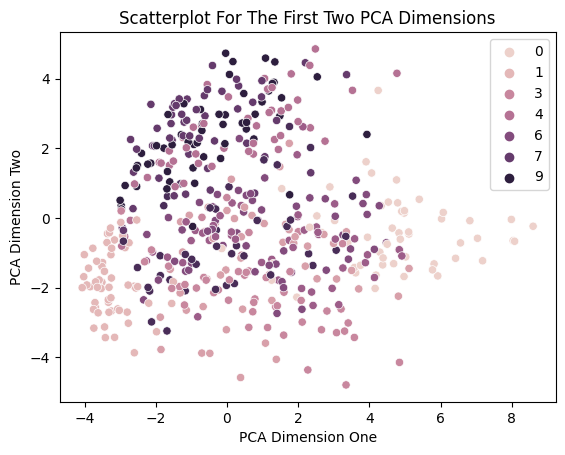

In [ ]:
# Scatter plot of first two PCA dimensions
import seaborn as sns  #sns.scatterplot(x, y, hue=labels)

plt.figure()
pcaT = pca.transform(x_train[train_indices['s']])
sns.scatterplot(x=pcaT[:, 0], y=pcaT[:, 1], hue=y_train[train_indices['s']])
plt.xlabel('PCA Dimension One')
plt.ylabel('PCA Dimension Two')
plt.title("Scatterplot For The First Two PCA Dimensions")
plt.show()

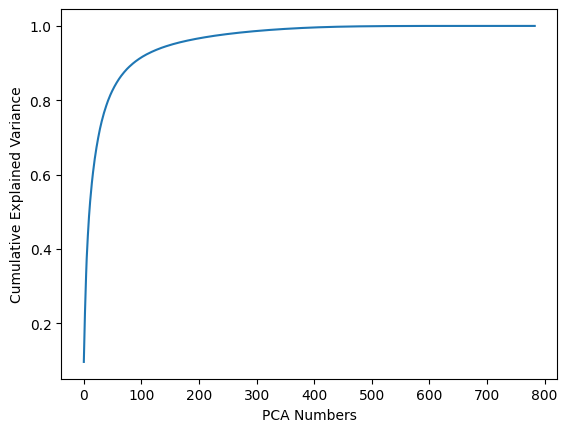

In [ ]:
# Plot cumulative explained variance
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
CEV = np.cumsum(pca.explained_variance_ratio_)
plt.xlabel('PCA Numbers')
plt.ylabel('Cumulative Explained Variance')
plt.show()

The first 10 samples before PCA compression


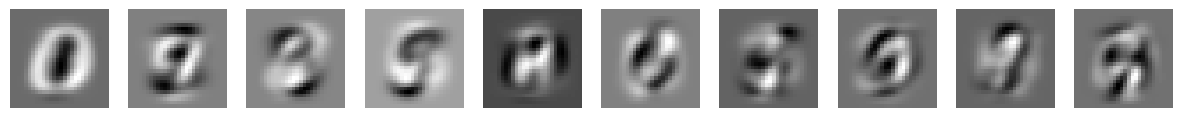

The first 10 samples after PCA compression


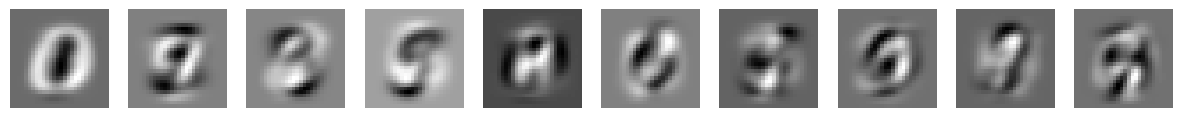

Brute Force: The Number Of Dimentions are: 88, The Test Error Is: 0.0286, The Add Time Is: 0.0177s, The Search Time Is: 2.6160s, The Total Time Is: 2.6336s


In [ ]:
# Select number of dimensions that explains 90% of variance, according to your plot above
dimentions = np.where(CEV >= 0.90) [0] [0] + 1

# Display the first 10 samples before PCA compression.
print(f"The first 10 samples before PCA compression")
display_mnist(pca.components_[:10], 1, 10)

# PCA compression.
pca2 = PCA(n_components=dimentions)
pca2.fit(x_train)
xpca_train = pca2.transform(x_train)
xpca_test = pca2.transform(x_test)

# Display the first 10 samples after PCA compression.
print(f"The first 10 samples after PCA compression")
display_mnist(pca2.components_[:10], 1, 10)

# Initialize the index for Brute Force
dim = xpca_train.shape[1]

index_flatl2 = faiss.IndexFlatL2(dim)  

start_time = time.time()

# Add Data & Print time to add
index_flatl2.add(xpca_train)

add_time = time.time()

# Perform Search and Compute Time required
_, search = index_flatl2.search(xpca_test, 1)

search_time = time.time()

# Compute Test Error
test_error = (y_test != y_train[search.reshape(-1)]).mean()

AT = add_time-start_time
ST = search_time-add_time
TT = search_time - start_time

print(f"Brute Force: The Number Of Dimentions are: {dimentions}, The Test Error Is: {test_error:.4f}, The Add Time Is: {AT:.4f}s, The Search Time Is: {ST:.4f}s, The Total Time Is: {TT:.4f}s")

## Part 4: Stretch Goals
Include all your code used for part 4 in this section. You can copy-paste code from parts 1, 2 or 3 if it is re-usable.

In [ ]:
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import time
import faiss
from google.colab import drive
from google.colab.patches import cv2_imshow
import cv2

drive.mount('/content/drive')
datadir = "/content/drive/My Drive/CS441/hw4/" # revise as needed
im = cv2.imread(datadir + 'NPI.jpg')
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)/255  # converts to RGB ordering and values between 0 and 1
crop = cv2.imread(datadir + 'NPIC.jpg')
crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)/255

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def display_score_maps(im, score_map, thresh):
  '''
    Input: im (h, w, 3): RGB image
           score_map (h, w, 1) or (h*w, 1)
           thresh: floating point threshold, typically between -2 and 2
  '''
  plt.imshow(im)
  plt.axis('off')
  plt.show()
  plt.imshow(np.reshape(score_map, (im.shape[:2])))
  plt.axis('off')
  plt.show()
  plt.imshow(np.reshape(score_map>thresh, (im.shape[0], im.shape[1])), cmap='gray')
  plt.axis('off')
  plt.show()
  plt.imshow(np.tile(np.reshape(score_map>thresh, (im.shape[0], im.shape[1], 1)), (1,1,3))*im)
  plt.axis('off')
  plt.show()

In [ ]:
# estimate discrete pdf
def estimate_discrete_pdf(x, K, prior=1):
  '''
    Input: x(nx, ): an array of discrete values from 0 to K-1
           K: number of possible discrete values
           prior: initial count for each discrete value
    Output: p(nvalues, ): p[i] is the estimated probability of discrete value i
    
    This function can be used for Method 1 and Method 2
  '''

  p = np.ones(K,)*prior # initialize p 
  # TO DO: 
  # (1) loop through values
  for v in range(x.shape[0]):
    # (2) increment element of p corresponding to each value
    p[x[v]] += 1
  # (3) divide by sum of p    
  # Count the occurrences of each discrete value in x
  p /= p.sum()

  return p

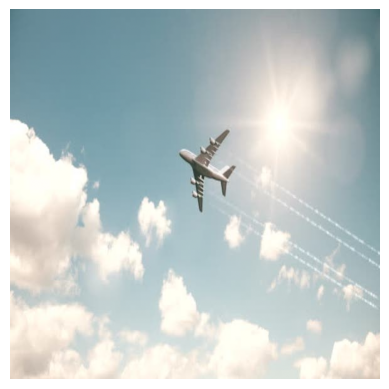

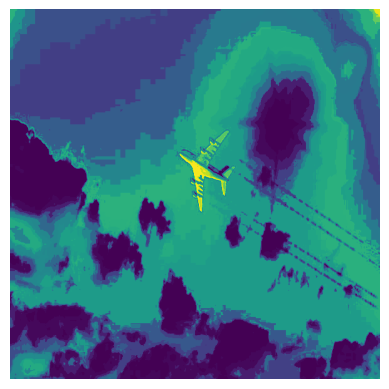

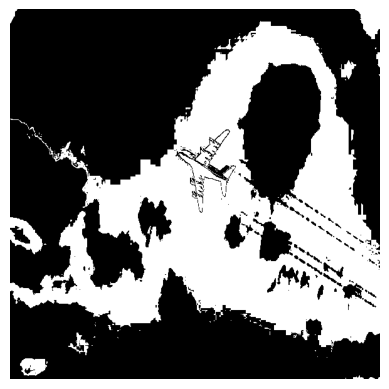

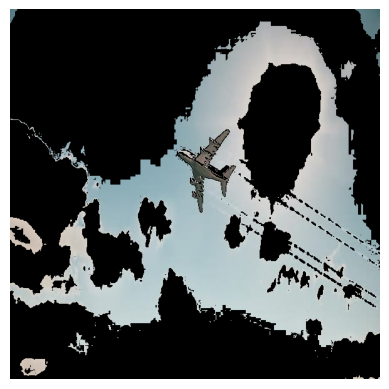

In [ ]:
# set number of bins K
K = 13

# reshape pixels to (h*w, 3)
CI = crop.reshape(-1, 3)
FI = im.reshape(-1, 3)

# convert continuous values to discrete values ranging from 0 to K-1 
# e.g. x-->min(int(x*K), K-1) if x ranges from 0 to 1
CD = np.minimum((CI * K).astype(int), K - 1)
FD = np.minimum((FI * K).astype(int), K - 1)

# get pdf for each dimension using estimate_discrete_pdf
CPDFLIST = []
FPDFLIST = []

for v in range(3):
  CPDF = estimate_discrete_pdf(CD[:, v], K)
  CPDFLIST.append(CPDF)
  FPDF = estimate_discrete_pdf(FD[:, v], K)
  FPDFLIST.append(FPDF)

# estimate score for each pixel in full image according to log pdfs
PDFLOGLIST = []

for v in range(3):
    PDFL = np.log(CPDFLIST[v][FD[:, v]] / FPDFLIST[v][FD[:, v]])
    PDFLOGLIST.append(PDFL)

# display
ScoreMapImage = np.sum(PDFLOGLIST, axis=0)
ThresholdImage = 0.6

display_score_maps(im, ScoreMapImage, ThresholdImage)

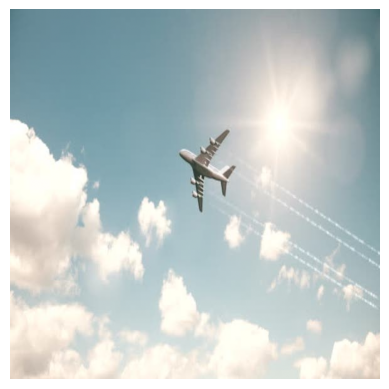

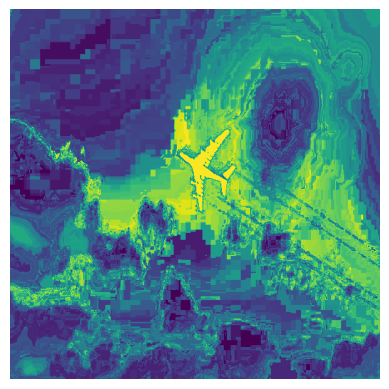

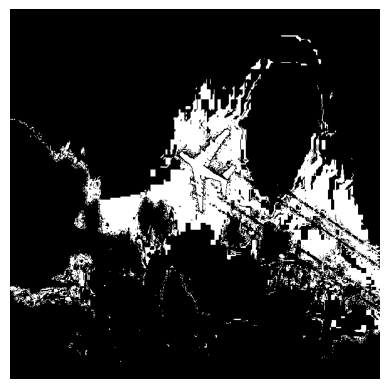

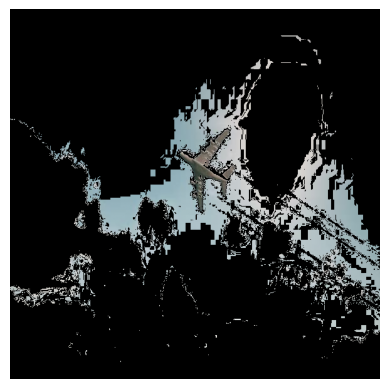

In [ ]:
import faiss

# set K
K = 501

# reshape pixels to (h*w, 3)
CI = crop.reshape(-1, 3)
FI = im.reshape(-1, 3)

# discretize all three color channels together using KMeans
kmeans = faiss.Kmeans(3, K)
kmeans.train(FI)

_, CISearch = kmeans.index.search(CI, 1)
_, FISearch = kmeans.index.search(FI, 1)

# get pdf over discrete values
CIF = CISearch.flatten()
FIF = FISearch.flatten()

CPDFLIST = estimate_discrete_pdf(CISearch, K)
FPDFLIST = estimate_discrete_pdf(FISearch, K)

# estimate score for each pixel in full image according to log pdfs
PDFL = np.log(CPDFLIST[FISearch] / FPDFLIST[FISearch])
PDFLF = PDFL.flatten()

# display
ScoreMapImage = PDFL
ThresholdImage = 0.6

display_score_maps(im, ScoreMapImage, ThresholdImage)

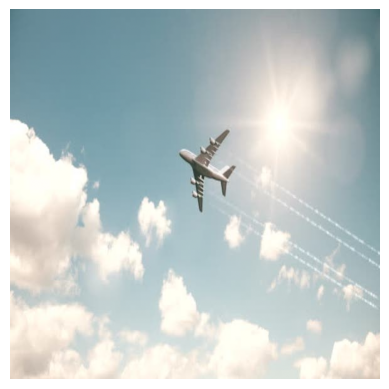

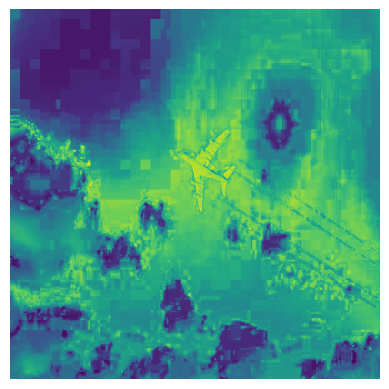

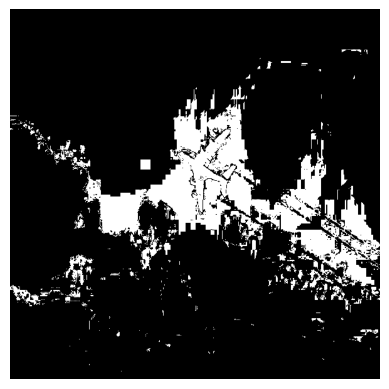

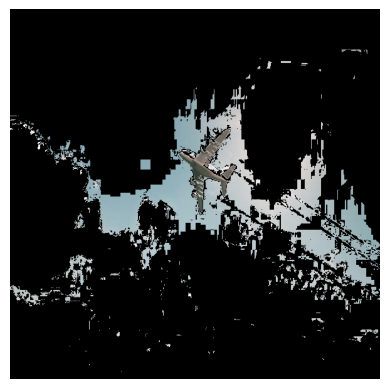

In [ ]:
from sklearn.mixture import GaussianMixture

# reshape pixels to (h*w, 3)
CI = crop.reshape(-1, 3)
FI = im.reshape(-1, 3)

# get joint pdf using GMMs (choose number of components and other parameters)
JPDFGMMCI = GaussianMixture(n_components=8, covariance_type='full')
JPDFGMMFI = GaussianMixture(n_components=8, covariance_type='full')

JPDFGMMCI.fit(CI)
JPDFGMMFI.fit(FI)

# estimate score for each pixel in full image according to log pdfs
LPDFCI = JPDFGMMCI.score_samples(FI)
LPDFFI = JPDFGMMFI.score_samples(FI)

# display
ScoreMapImage = LPDFCI - LPDFFI
ThresholdImage = 0.6

display_score_maps(im, ScoreMapImage, ThresholdImage)

In [ ]:
# Importing the PCS and seaborn libraries.
from sklearn.decomposition import PCA
import seaborn as sns 

# Creating the PCA model and training the PCA model.
pca = PCA()
pca.fit(x_train)

PCA()

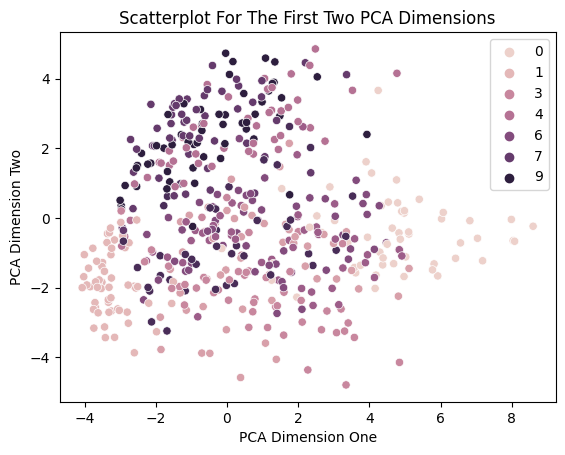

In [ ]:
# Plotting the PCA scatterplot.
plt.figure()
pcaT = pca.transform(x_train[train_indices['s']])
sns.scatterplot(x=pcaT[:, 0], y=pcaT[:, 1], hue=y_train[train_indices['s']])
plt.xlabel('PCA Dimension One')
plt.ylabel('PCA Dimension Two')
plt.title("Scatterplot For The First Two PCA Dimensions")
plt.show()

In [ ]:
# Importing the TSNE and seaborn libraries.
from sklearn.manifold import TSNE
import seaborn as sns 

# Creating the TSNE model and training the TSNE model.
tsne = TSNE()
tsneT = tsne.fit_transform(x_train[train_indices['s']])

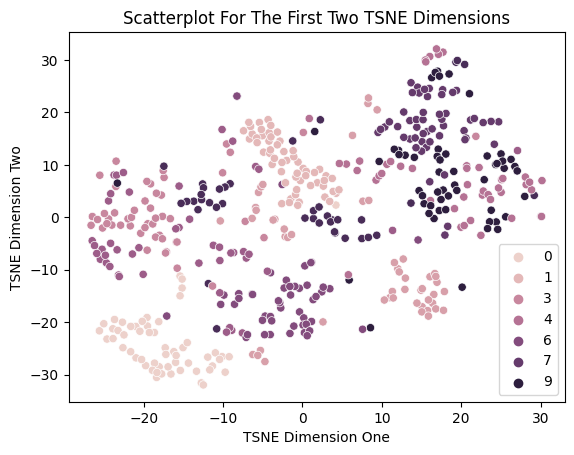

In [ ]:
# Plotting the TSNE scatterplot.
plt.figure()
sns.scatterplot(x=tsneT[:, 0], y=tsneT[:, 1], hue=y_train[train_indices['s']])
plt.xlabel('TSNE Dimension One')
plt.ylabel('TSNE Dimension Two')
plt.title("Scatterplot For The First Two TSNE Dimensions")
plt.show()

In [ ]:
# Importing the MDS and seaborn libraries.
from sklearn.manifold import MDS
import seaborn as sns 

# Creating the MDS model and training the MDS model.
mds = MDS()
mdsT = mds.fit_transform(x_train[train_indices['s']])

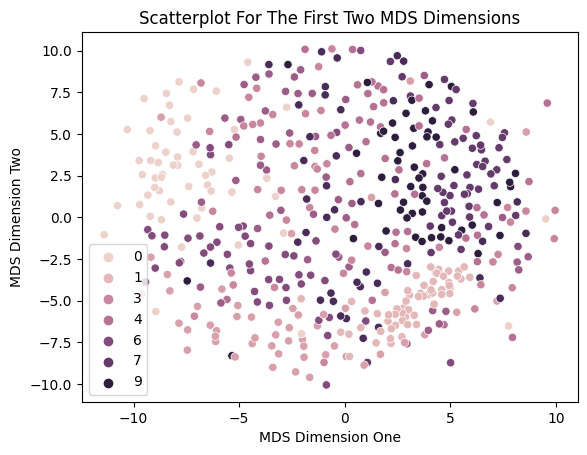

In [ ]:
# Plotting the MDS scatterplot.
plt.figure()
sns.scatterplot(x=mdsT[:, 0], y=mdsT[:, 1], hue=y_train[train_indices['s']])
plt.xlabel('MDS Dimension One')
plt.ylabel('MDS Dimension Two')
plt.title("Scatterplot For The First Two MDS Dimensions")
plt.show()

In [ ]:
# Importing the LDA and seaborn libraries.
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import seaborn as sns 

# Creating the LDA model and training the LDA model.
lda = LDA()
ldaT = lda.fit_transform(x_train[train_indices['s']], y_train[train_indices['s']])

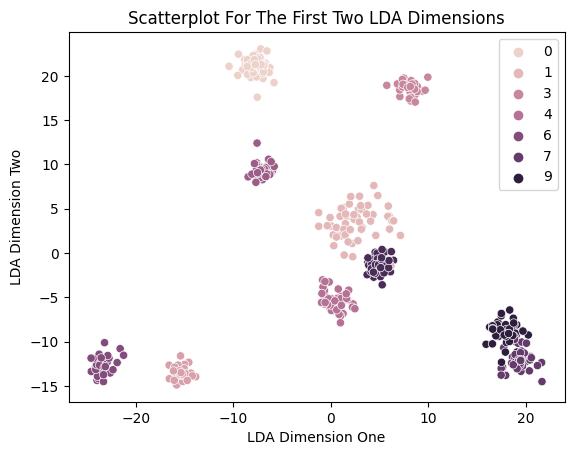

In [ ]:
# Plotting the LDA scatterplot.
plt.figure()
sns.scatterplot(x=ldaT[:, 0], y=ldaT[:, 1], hue=y_train[train_indices['s']])
plt.xlabel('LDA Dimension One')
plt.ylabel('LDA Dimension Two')
plt.title("Scatterplot For The First Two LDA Dimensions")
plt.show()